In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# -------------------------------
# Load MNIST Dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the images
x_train = x_train / 255.0
x_test = x_test / 255.0


In [5]:
# -------------------------------
# Function to Create Model
# -------------------------------
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [6]:
# -------------------------------
# Train with SGD
# -------------------------------
model_sgd = create_model()
model_sgd.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

C:\Users\Hp\anaconda3\envs\abcdefgh\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8109 - loss: 0.7047 - val_accuracy: 0.9077 - val_loss: 0.3387
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9118 - loss: 0.3141 - val_accuracy: 0.9235 - val_loss: 0.2702
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9267 - loss: 0.2583 - val_accuracy: 0.9358 - val_loss: 0.2300
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9359 - loss: 0.2243 - val_accuracy: 0.9434 - val_loss: 0.2039
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9429 - loss: 0.1993 - val_accuracy: 0.9463 - val_loss: 0.1922


In [7]:
# -------------------------------
# Train with RMSProp
# -------------------------------
model_rms = create_model()
model_rms.compile(optimizer='rmsprop',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_rms = model_rms.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9238 - loss: 0.2599 - val_accuracy: 0.9580 - val_loss: 0.1418
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9652 - loss: 0.1171 - val_accuracy: 0.9553 - val_loss: 0.1625
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9745 - loss: 0.0845 - val_accuracy: 0.9705 - val_loss: 0.1066
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9804 - loss: 0.0654 - val_accuracy: 0.9688 - val_loss: 0.1117
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9836 - loss: 0.0544 - val_accuracy: 0.9736 - val_loss: 0.1114


In [8]:
# -------------------------------
# Train with Adam
# -------------------------------
model_adam = create_model()
model_adam.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9235 - loss: 0.2643 - val_accuracy: 0.9559 - val_loss: 0.1458
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9663 - loss: 0.1130 - val_accuracy: 0.9672 - val_loss: 0.1025
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9765 - loss: 0.0771 - val_accuracy: 0.9706 - val_loss: 0.0914
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9813 - loss: 0.0589 - val_accuracy: 0.9726 - val_loss: 0.0919
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9851 - loss: 0.0463 - val_accuracy: 0.9668 - val_loss: 0.1124


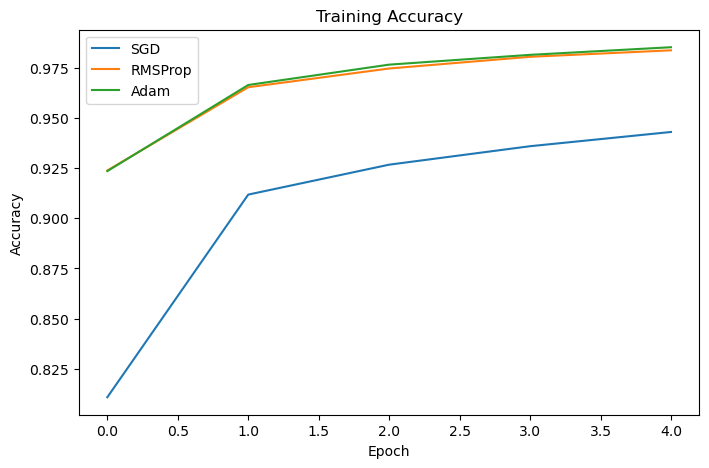

In [9]:
# -------------------------------
# Plot Accuracy
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['accuracy'], label='SGD')
plt.plot(history_rms.history['accuracy'], label='RMSProp')
plt.plot(history_adam.history['accuracy'], label='Adam')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

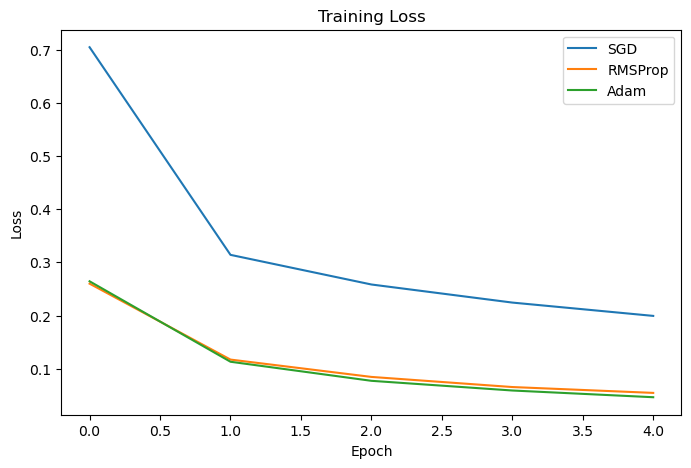

In [10]:
# -------------------------------
# Plot Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_rms.history['loss'], label='RMSProp')
plt.plot(history_adam.history['loss'], label='Adam')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [11]:
# -------------------------------
# Evaluate Models
# -------------------------------
sgd_loss, sgd_acc = model_sgd.evaluate(x_test, y_test, verbose=0)
rms_loss, rms_acc = model_rms.evaluate(x_test, y_test, verbose=0)
adam_loss, adam_acc = model_adam.evaluate(x_test, y_test, verbose=0)

# -------------------------------
# Comparison Table
# -------------------------------
results = pd.DataFrame({
    "Optimizer": ["SGD", "RMSProp", "Adam"],
    "Accuracy": [sgd_acc, rms_acc, adam_acc],
    "Loss": [sgd_loss, rms_loss, adam_loss]
})

print("\nOptimizer Comparison")
print(results)


Optimizer Comparison
  Optimizer  Accuracy      Loss
0       SGD    0.9444  0.189675
1   RMSProp    0.9744  0.096463
2      Adam    0.9740  0.087567


In [12]:
# -------------------------------
# Best Optimizer
# -------------------------------
best = results.loc[results["Accuracy"].idxmax()]

print("\nBest Optimizer:", best["Optimizer"])
print("Highest Accuracy:", round(best["Accuracy"], 4))
print("Lowest Loss:", round(best["Loss"], 4))

print("\nConclusion:")
print(f"{best['Optimizer']} performed the best because it achieved the highest accuracy ({best['Accuracy']:.4f}) and the lowest loss ({best['Loss']:.4f}).")


Best Optimizer: RMSProp
Highest Accuracy: 0.9744
Lowest Loss: 0.0965

Conclusion:
RMSProp performed the best because it achieved the highest accuracy (0.9744) and the lowest loss (0.0965).
